**Import Packages**

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


**Read the Data**

In [53]:
yemen_df = pd.read_csv("yemen_hrp_political_violence.csv")
yemen_df.head()

,Country,Admin1,Admin2,ISO3,Admin2 Pcode,Admin1 Pcode,Month,Year,Events,Fatalities
0,Yemen,Al Jawf,Rajuzah,YEM,YE1611,YE16,January,2015,0,0
1,Yemen,Al Jawf,Khabb wa Ash Shaaf,YEM,YE1601,YE16,January,2015,0,0
2,Yemen,Amanat al Asimah,Bani Al Harith,YEM,YE1310,YE13,January,2015,1,2
3,Yemen,Shabwah,Mayfaa,YEM,YE2116,YE21,January,2015,1,0
4,Yemen,Al Hudaydah,Al Hawak,YEM,YE1821,YE18,January,2015,1,0


In [54]:
yemen_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45954 entries, 0 to 45953
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Country       45954 non-null  str  
 1   Admin1        45954 non-null  str  
 2   Admin2        45954 non-null  str  
 3   ISO3          45954 non-null  str  
 4   Admin2 Pcode  45954 non-null  str  
 5   Admin1 Pcode  45954 non-null  str  
 6   Month         45954 non-null  str  
 7   Year          45954 non-null  int64
 8   Events        45954 non-null  int64
 9   Fatalities    45954 non-null  int64
dtypes: int64(3), str(7)
memory usage: 3.5 MB


**Overall Statistics**

1. Events and Fatalities

In [55]:
yemen_df[["Events", "Fatalities"]].agg(["mean", "std", "max", "sum"])

,Events,Fatalities
mean,1.773426,3.56587
std,6.429686,19.77325
max,126.000000,893.00000
sum,81496.000000,163866.00000


In [56]:
# Create Date column (first day of each month)
yemen_df["Date"] = pd.to_datetime(
    yemen_df["Month"] + " " + yemen_df["Year"].astype(str),
    format="%B %Y"
)

# Format as Month-Year
yemen_df["Date"] = pd.to_datetime(yemen_df["Date"], format="%b-%Y")

yemen_df[["Month", "Year", "Date"]].head()

,Month,Year,Date
0,January,2015,2015-01-01
1,January,2015,2015-01-01
2,January,2015,2015-01-01
3,January,2015,2015-01-01
4,January,2015,2015-01-01


**Yearly Fatalities**

In [57]:
yearly_fatalities = (
    yemen_df.groupby(['Year'])['Fatalities']
      .sum()
      .reset_index()
)
yearly_fatalities = yearly_fatalities.sort_values(
    by='Year'
).reset_index(drop=True)

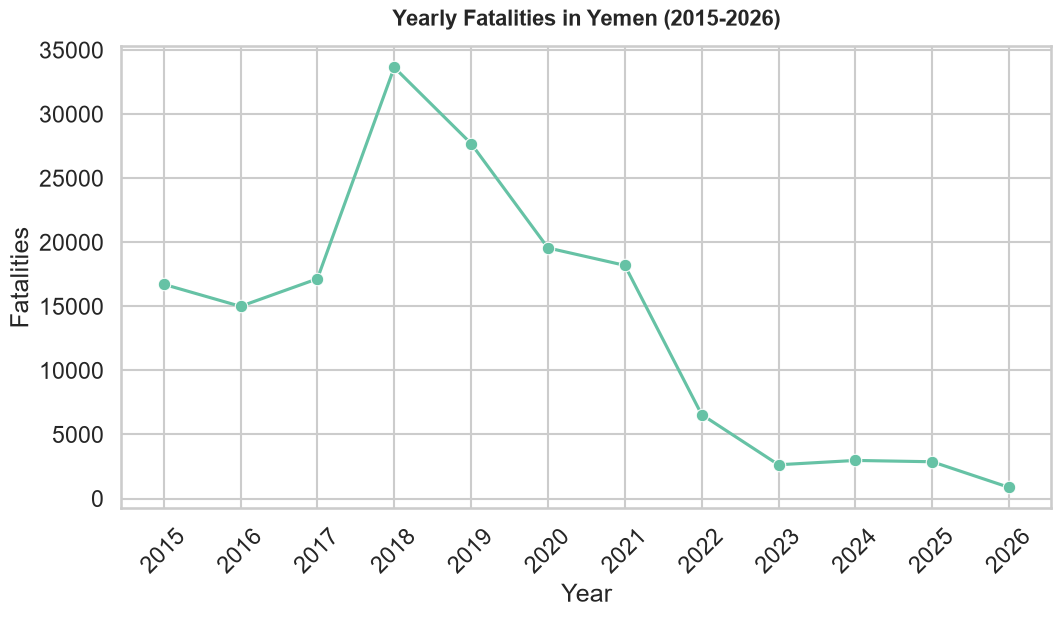

In [135]:
plt.figure(figsize = (12, 6))

sns.set(style="whitegrid")
sns.set_palette("Set2")
sns.set_context("talk")
sns.lineplot(data=yearly_fatalities, x='Year', y='Fatalities', marker='o')
plt.title("Yearly Fatalities in Yemen (2015-2026)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.xticks(yearly_fatalities['Year'], rotation=45)
plt.show()

**Monthly Fatalities**

In [59]:
# Group by Date and count monthly Fatalities
monthly_fatalities = (
    yemen_df.groupby('Date')['Fatalities']
      .sum()
      .reset_index()
)

In [73]:
monthly_fatalities.head()

,Date,Fatalities
0,2015-01-01,293
1,2015-02-01,310
2,2015-03-01,1132
3,2015-04-01,2632
4,2015-05-01,1895


In [68]:
print(monthly_fatalities[(monthly_fatalities['Date'].between("2015-04-01", "2022-03-01"))]['Fatalities'].sum())

150640


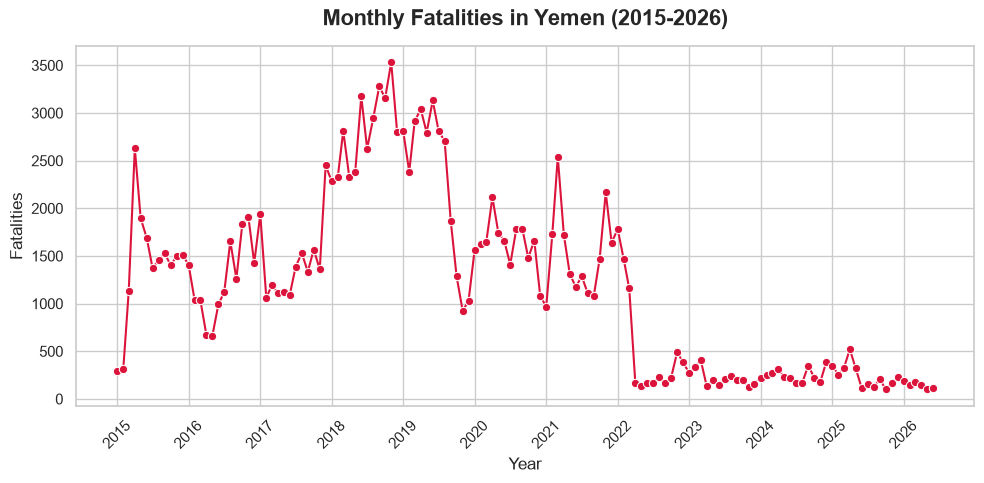

In [136]:
# 3. Set a visually appealing Seaborn theme
sns.set_theme(style="whitegrid")

# 4. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# 5. Plot the historical line chart
sns.lineplot(data=monthly_fatalities, x='Date', y='Fatalities', marker='o', color='crimson', ax=ax)

# 2. Fix the overlapping text: Set major ticks to show only once a year
ax.xaxis.set_major_locator(mdates.YearLocator())

# 3. Format how the date looks (e.g., '2024' or '2024-01')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 4. Optional: Add minor ticks for every month without adding text labels
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.xticks(rotation=45)
plt.title("Monthly Fatalities in Yemen (2015-2026)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.tight_layout()
plt.show()

Between 2015 and 2026, approximately 164,000 fatalities were recorded as a result of political violence in Yemen. The overwhelming majority of these deaths, about 151,000 (approximately 92%), occurred during the period of the Saudi Arabia- and UAE-led military intervention between April 2015 and March 2022, highlighting the intensity of the conflict during this phase. Conflict-related fatalities peaked in 2018, when nearly 34,000 people were killed. The deadliest month was November 2018, with more than 3,500 fatalities, reflecting a period of exceptionally intense military activity.

**Fatalities by Governorates**

In [78]:
fatalities_by_governorate_df = (
    yemen_df.groupby('Admin1')['Fatalities']
    .sum()
    .reset_index()
    .sort_values(by='Fatalities', ascending=False)
    .reset_index(drop=True)
)

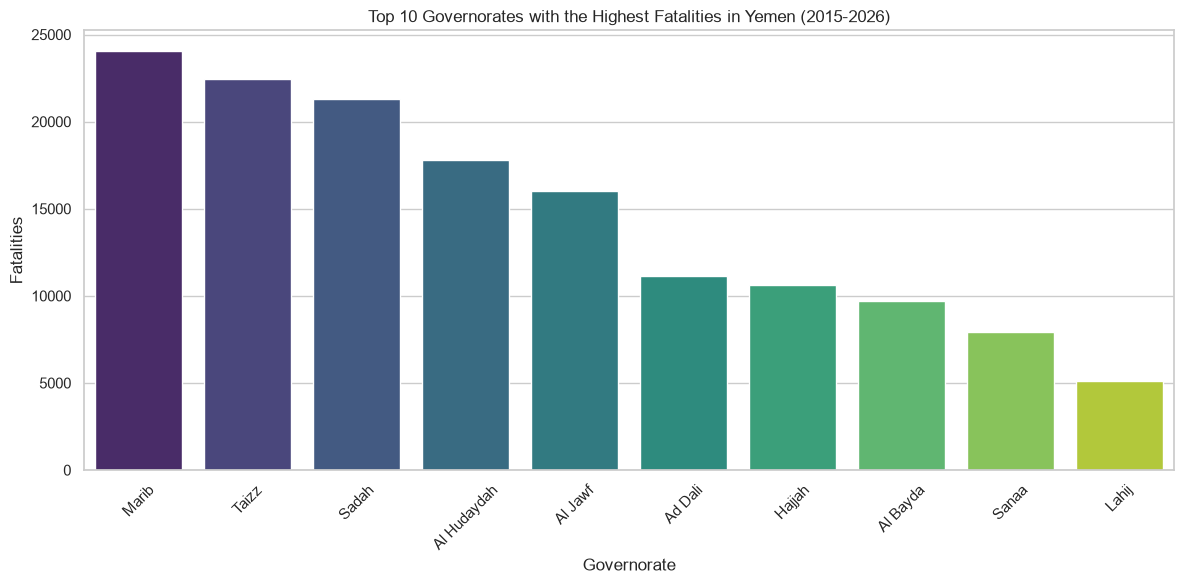

In [81]:
# Top 10 governorates with the highest fatalities
top_10_governorates = fatalities_by_governorate_df.head(10)

# Create a bar plot for the top 10 governorates
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_governorates, x='Admin1', y='Fatalities', hue='Admin1', dodge=False, palette='viridis')
plt.title("Top 10 Governorates with the Highest Fatalities in Yemen (2015-2026)")
plt.xlabel("Governorate")
plt.ylabel("Fatalities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [84]:
top_10_governorates['Fatalities'].sum() / fatalities_by_governorate_df['Fatalities'].sum() * 100

np.float64(89.08864560067371)

In [85]:
# Total number of governorates in Yemen
total_governorates = yemen_df['Admin1'].nunique()
total_governorates

22

In [89]:
top_10_governorates['Fatalities'].head(5).sum()

np.int64(101552)

**Conflict-related fatalities in Yemen were highly concentrated geographically**. Although Yemen is divided into 22 governorates, the 10 governorates with the highest fatality counts accounted for more than **146,000 deaths**, representing approximately **89% of all recorded fatalities** between 2015 and 2026. This indicates that the most severe violence was concentrated in fewer than half of the country's governorates, while the remaining 12 governorates collectively accounted for only about 11% of total fatalities.

The unequal distribution of fatalities suggests that the conflict was characterized by persistent geographic hotspots rather than uniformly distributed violence. Governorates such as **Marib, Taiz, Sa'dah, Al Hudaydah, and Al Jawf** experienced sustained, high-intensity conflict, reflecting their strategic military, political, and logistical importance throughout the conflict period. The 5 goverorates recorded more than **101,500 fatalities**, accounting for approximately **62% of all conflict-related deaths** in Yemen between 2015 and 2026. They experienced nearly **two-thirds of all recorded fatalities** during this study period. These areas were the sites of sustained military operations, repeated territorial contests, and prolonged armed confrontations, making them the primary drivers of nationwide conflict mortality.

| Group        |   Number of Governorates | Fatalities | Share of Total Fatalities |
| ------------ | -----------------------: | ---------: | ------------------------: |
| Top 5        |  5 (23% of governorates) |   ~101,500 |                      ~62% |
| Top 10       | 10 (45% of governorates) |   ~146,000 |                      ~89% |
| Remaining 12 | 12 (55% of governorates) |    ~18,000 |                      ~11% |

- **The top 5 governorates alone accounted for nearly two-thirds of all fatalities.**
- **Expanding to the top 10 governorates captured almost nine out of every ten fatalities.**
- **The remaining 12 governorates collectively accounted for only about 11% of fatalities**, underscoring the highly uneven geographic distribution of conflict intensity.

In [113]:
yemen_df['Admin2'].nunique()

332

In [114]:
fatalities_by_admin2_df = (
    yemen_df.groupby(['Admin1', 'Admin2'])['Fatalities']
    .sum()
    .reset_index()
    .sort_values(by='Fatalities', ascending=False)
    .reset_index(drop=True)
)

fatalities_by_admin2_df.head(20)

,Admin1,Admin2,Fatalities
0,Marib,Sirwah,11032
1,Ad Dali,Qaatabah,7361
2,Sadah,Kitaf wa Al Boqee,6840
3,Al Jawf,Khabb wa Ash Shaaf,6788
4,Sanaa,Nihm,6691
5,Sadah,Baqim,6007
6,Al Hudaydah,At Tuhayat,4264
7,Hajjah,Haradh,4206
8,Al Hudaydah,Ad Durayhimi,3949
9,Al Hudaydah,Hays,3461


In [115]:
marib_df = fatalities_by_admin2_df[fatalities_by_admin2_df['Admin1'] == 'Marib']
marib_df['Admin2'].nunique()

14

**Geographic Distribution of Conflict Fatalities - Governorates**

--- Dataset Analytics ---
Total Governorates analyzed: 22
Total Fatalities recorded:    163,866
Calculated Gini Coefficient: 0.5684



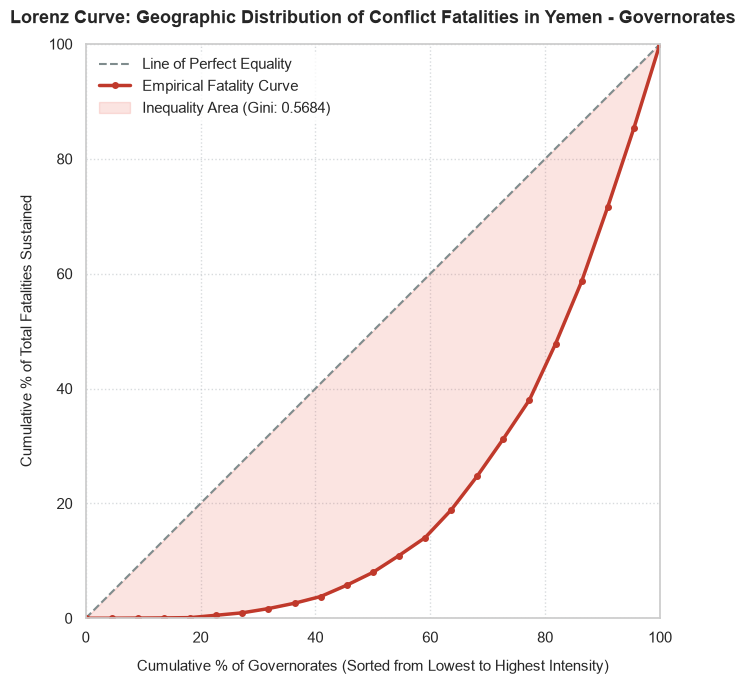

In [131]:
# =====================================================================
# 1. MATHEMATICAL SORTING AND CUMULATIVE CALCULATIONS
# =====================================================================
# Sort governorates from lowest fatalities to highest (required for Lorenz Curve)
fatalities_by_governorate_df = fatalities_by_governorate_df.sort_values(by='Fatalities', ascending=True).reset_index(drop=True)

total_govs = len(fatalities_by_governorate_df)
total_fatalities = fatalities_by_governorate_df['Fatalities'].sum()

# Compute cumulative percentages
# We insert a 0 at index 0 to ensure the curve starts properly at the origin (0,0)
cum_govs_pct = np.insert((fatalities_by_governorate_df.index + 1) / total_govs * 100, 0, 0)
cum_fatalities_pct = np.insert(fatalities_by_governorate_df['Fatalities'].cumsum() / total_fatalities * 100, 0, 0)

# =====================================================================
# 2. EXACT GINI COEFFICIENT CALCULUS (Trapezoidal Integration)
# =====================================================================
# Area under the Lorenz curve calculation
area_under_lorenz = 0
for i in range(total_govs):
    dx = 1 / total_govs
    y1 = cum_fatalities_pct[i] / 100
    y2 = cum_fatalities_pct[i+1] / 100
    area_under_lorenz += 0.5 * (y1 + y2) * dx

# Gini = (Area between Equality Line and Lorenz) / (Total Area under Equality Line)
gini_coefficient = (0.5 - area_under_lorenz) / 0.5

print(f"--- Dataset Analytics ---")
print(f"Total Governorates analyzed: {total_govs}")
print(f"Total Fatalities recorded:    {total_fatalities:,}")
print(f"Calculated Gini Coefficient: {gini_coefficient:.4f}\n")

# =====================================================================
# 3. PLOT THE EMPIRICAL LORENZ CURVE
# =====================================================================
plt.figure(figsize=(7, 7), dpi=100)

# Line of Perfect Equality
plt.plot([0, 100], [0, 100], color='#7f8c8d', linestyle='--', linewidth=1.5, label='Line of Perfect Equality')

# Empirical Yemen Lorenz Curve from your actual data
plt.plot(cum_govs_pct, cum_fatalities_pct, marker='o', color='#c0392b', linewidth=2.5, markersize=4, label='Empirical Fatality Curve')

# Shaded Area showing the visual degree of concentration inequality
plt.fill_between(cum_govs_pct, cum_govs_pct, cum_fatalities_pct, color='#e74c3c', alpha=0.15, label=f'Inequality Area (Gini: {gini_coefficient:.4f})')

# Clean up layout, labels and design parameters
plt.title('Lorenz Curve: Geographic Distribution of Conflict Fatalities in Yemen - Governorates', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Cumulative % of Governorates (Sorted from Lowest to Highest Intensity)', fontsize=11, labelpad=10)
plt.ylabel('Cumulative % of Total Fatalities Sustained', fontsize=11, labelpad=10)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(True, linestyle=':', alpha=0.6, color='#bdc3c7')
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# Add subtle axis limits formatting
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [110]:
district_summary = (
    yemen_df.groupby('Admin2')['Fatalities']
    .sum()
    .reset_index()
)

district_summary

,Admin2,Fatalities
0,Abs,1134
1,Ad Dahi,29
2,Ad Dhalee,1615
3,Ad Dis,0
4,Ad Durayhimi,3949
...,...,...
327,Yahr,2
328,Yarim,148
329,Zabid,330
330,Zamakh wa Manwakh,17


**Geographic Distribution of Conflict Fatalities - Districts**

In [133]:
# Sort districts from lowest fatalities to highest (required for Lorenz Curve)
district_summary = district_summary.sort_values(by='Fatalities', ascending=True).reset_index(drop=True)

total_districts = len(district_summary)

# Compute cumulative percentages
# We insert a 0 at index 0 to ensure the curve starts properly at the origin (0,0)
cum_districts_pct = np.insert((district_summary.index + 1) / total_districts * 100, 0, 0)
cum_fatalities_pct = np.insert(district_summary['Fatalities'].cumsum() / district_summary['Fatalities'].sum() * 100, 0, 0)

# Area under the Lorenz curve calculation
area_under_lorenz = 0
for i in range(total_districts):
    dx = 1 / total_districts
    y1 = cum_fatalities_pct[i] / 100
    y2 = cum_fatalities_pct[i+1] / 100
    area_under_lorenz += 0.5 * (y1 + y2) * dx

# Gini = (Area between Equality Line and Lorenz) / (Total Area under Equality Line)
gini_coefficient = (0.5 - area_under_lorenz) / 0.5

print(f"--- Dataset Analytics ---")
print(f"Total Districts analyzed: {total_districts}")
print(f"Total Fatalities recorded:    {total_fatalities:,}")
print(f"Calculated Gini Coefficient: {gini_coefficient:.4f}\n")

--- Dataset Analytics ---
Total Districts analyzed: 332
Total Fatalities recorded:    163,866
Calculated Gini Coefficient: 0.7906



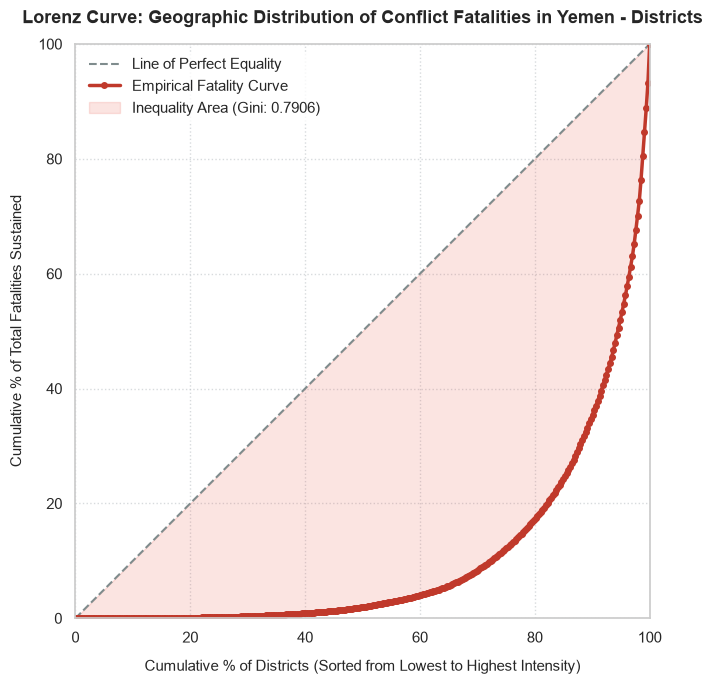

In [134]:
plt.figure(figsize=(7, 7), dpi=100)

# Line of Perfect Equality
plt.plot([0, 100], [0, 100], color='#7f8c8d', linestyle='--', linewidth=1.5, label='Line of Perfect Equality')

# Empirical Yemen Lorenz Curve from your actual data
plt.plot(cum_districts_pct, 
         cum_fatalities_pct, 
         marker='o', 
         color='#c0392b', 
         linewidth=2.5, 
         markersize=4, 
         label='Empirical Fatality Curve')

# Shaded Area showing the visual degree of concentration inequality
plt.fill_between(cum_districts_pct, 
                 cum_districts_pct, 
                 cum_fatalities_pct, 
                 color='#e74c3c', alpha=0.15, 
                 label=f'Inequality Area (Gini: {gini_coefficient:.4f})')

# Clean up layout, labels and design parameters
plt.title('Lorenz Curve: Geographic Distribution of Conflict Fatalities in Yemen - Districts', 
          fontsize=13, 
          fontweight='bold', 
          pad=15)
plt.xlabel('Cumulative % of Districts (Sorted from Lowest to Highest Intensity)', 
           fontsize=11, 
           labelpad=10)
plt.ylabel('Cumulative % of Total Fatalities Sustained', 
           fontsize=11, 
           labelpad=10)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(True, linestyle=':', alpha=0.6, color='#bdc3c7')
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# Add subtle axis limits formatting
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()